In [2]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
import joblib

# 数据路径 & cache 文件夹
features_file = "../data/steam_games_features.csv"
os.makedirs("../cache", exist_ok=True)

# 加载数据
df = pd.read_csv(features_file)
df = df.sort_values('positive', ascending=False).head(5000).reset_index(drop=True)
print("热门游戏前5000条：", df.shape)



热门游戏前5000条： (5000, 31)


In [3]:
num_features = ['log1p_price','log1p_positive','log1p_negative','log1p_recommendations',
                'average_playtime_forever','weighted_score']
scaled_features_file = "../cache/scaled_features.pkl"

if os.path.exists(scaled_features_file):
    print("加载已缓存的数值特征...")
    df_scaled = joblib.load(scaled_features_file)
else:
    print("计算数值特征并缓存...")
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df[num_features])
    df_scaled = pd.DataFrame(df_scaled, columns=[f'scaled_{c}' for c in num_features])
    joblib.dump(df_scaled, scaled_features_file)


加载已缓存的数值特征...


In [4]:
text_emb_file = "../cache/text_embeddings.npy"
if os.path.exists(text_emb_file):
    print("加载已缓存的文本 embedding...")
    text_embeddings = np.load(text_emb_file)
else:
    print("计算文本 embedding 并缓存...")
    text_model = SentenceTransformer('all-MiniLM-L6-v2')
    text_embeddings = np.array([text_model.encode(x) for x in df['text_features']])
    np.save(text_emb_file, text_embeddings)


加载已缓存的文本 embedding...


In [5]:
from sklearn.feature_extraction.text import CountVectorizer

tag_matrix_file = "../cache/tag_matrix.npy"
tag_weight_file = "../cache/tag_weight.npy"
tag_names_file = "../cache/tag_names.pkl"

df['tags_str'] = df['tags'].fillna("").apply(lambda x: " ".join(x.split(',')))

if os.path.exists(tag_matrix_file) and os.path.exists(tag_weight_file) and os.path.exists(tag_names_file):
    print("加载已缓存标签矩阵与权重...")
    tag_matrix = np.load(tag_matrix_file)
    tag_weight = np.load(tag_weight_file)
    tag_names = joblib.load(tag_names_file)
else:
    print("计算标签矩阵与权重并缓存...")
    vectorizer = CountVectorizer()
    tag_matrix = vectorizer.fit_transform(df['tags_str']).toarray()
    tag_names = vectorizer.get_feature_names_out()
    tag_weight = tag_matrix / (tag_matrix.sum(axis=1, keepdims=True) + 1e-6)

    np.save(tag_matrix_file, tag_matrix)
    np.save(tag_weight_file, tag_weight)
    joblib.dump(tag_names, tag_names_file)


加载已缓存标签矩阵与权重...


In [6]:
features_combined_file = "../cache/features_combined.npy"
intent_labels_file = "../cache/intent_labels.npy"

features_combined = np.hstack([text_embeddings, df_scaled.values * 0.1])  # 数值特征加权

if os.path.exists(features_combined_file) and os.path.exists(intent_labels_file):
    print("加载已缓存特征和聚类标签...")
    features_combined = np.load(features_combined_file)
    intent_labels = np.load(intent_labels_file)
else:
    print("计算 PCA + KMeans 并缓存...")
    from sklearn.decomposition import PCA
    from sklearn.cluster import KMeans

    pca = PCA(n_components=50, random_state=42)
    features_reduced = pca.fit_transform(features_combined)
    
    kmeans = KMeans(n_clusters=12, random_state=42)
    intent_labels = kmeans.fit_predict(features_reduced)

    np.save(features_combined_file, features_combined)
    np.save(intent_labels_file, intent_labels)

df['intent_category'] = intent_labels


加载已缓存特征和聚类标签...


In [7]:
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import numpy as np

def jaccard_similarity(tags1, tags2):
    set1, set2 = set(tags1.split()), set(tags2.split())
    return len(set1 & set2) / (len(set1 | set2) + 1e-6)

class IntentAwareTripletDataset(Dataset):
    def __init__(self, features, tags_list, intent_list):
        self.features = features.astype(np.float32)
        self.tags_list = tags_list
        self.intent_list = np.array(intent_list)
        self.N = len(features)
    
    def __len__(self):
        return self.N

    def __getitem__(self, idx):
        anchor = torch.from_numpy(self.features[idx])

        sims = np.array([jaccard_similarity(self.tags_list[idx], t) for t in self.tags_list])
        pos_candidates = np.where((sims >= 0.5) & (self.intent_list == self.intent_list[idx]))[0]
        neg_candidates = np.where((sims <= 0.2) | (self.intent_list != self.intent_list[idx]))[0]

        pos_candidates = pos_candidates[pos_candidates != idx]
        neg_candidates = neg_candidates[neg_candidates != idx]

        pos_idx = np.random.choice(pos_candidates) if len(pos_candidates) > 0 else np.random.randint(0, self.N)
        neg_idx = np.random.choice(neg_candidates) if len(neg_candidates) > 0 else np.random.randint(0, self.N)

        positive = torch.from_numpy(self.features[pos_idx])
        negative = torch.from_numpy(self.features[neg_idx])

        return anchor, positive, negative

dataset = IntentAwareTripletDataset(features_combined, df['tags'].values, df['intent_category'].values)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)


In [8]:
class DeepTripletNet(nn.Module):
    def __init__(self, input_dim, hidden_dims=[512,256,128], dropout=0.2):
        super().__init__()
        layers = []
        last_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(last_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            last_dim = h
        self.fc = nn.Sequential(*layers)

    def forward(self, anchor, positive, negative):
        return self.fc(anchor), self.fc(positive), self.fc(negative)

    def embed(self, x):
        return self.fc(x)


In [9]:
model_file = "../cache/deep_triplet_model.pth"
final_emb_file = "../cache/final_embeddings.npy"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DeepTripletNet(features_combined.shape[1]).to(device)

if os.path.exists(final_emb_file):
    print("加载已缓存的最终 embedding...")
    embeddings = np.load(final_emb_file)
else:
    if os.path.exists(model_file):
        print("加载已训练模型权重...")
        model.load_state_dict(torch.load(model_file))
    else:
        print("开始训练模型...")
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        triplet_loss = nn.TripletMarginLoss(margin=1.0)
        epochs = 20

        for epoch in range(epochs):
            total_loss = 0
            for anchor, positive, negative in dataloader:
                anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)
                optimizer.zero_grad()
                out_a, out_p, out_n = model(anchor, positive, negative)
                loss = triplet_loss(out_a, out_p, out_n)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            print(f"Epoch {epoch+1}/{epochs}, Loss={total_loss/len(dataloader):.4f}")
        torch.save(model.state_dict(), model_file)

    model.eval()
    with torch.no_grad():
        features_tensor = torch.tensor(features_combined, dtype=torch.float32).to(device)
        embeddings = model.fc(features_tensor).cpu().numpy()
        np.save(final_emb_file, embeddings)


加载已缓存的最终 embedding...


In [10]:
import faiss

d = embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(d)
faiss.normalize_L2(embeddings)
faiss_index.add(embeddings)


In [11]:
import math
from collections import Counter

core_tags_file = "../cache/core_tags.pkl"
idf_file = "../cache/tag_idf.pkl"

# 计算 IDF 并缓存
if os.path.exists(core_tags_file) and os.path.exists(idf_file):
    print("加载已缓存的核心玩法...")
    df['core_tags'] = joblib.load(core_tags_file)
    idf = joblib.load(idf_file)
else:
    print("计算核心玩法与 IDF 并缓存...")
    all_tags_list = df['tags'].apply(lambda x: x.split())
    tag_doc_count = Counter()
    for tags in all_tags_list:
        tag_doc_count.update(set(tags))
    total_games = len(df)
    idf = {tag: math.log(total_games / (count+1)) for tag, count in tag_doc_count.items()}

    def get_core_tags(tags_str, top_n=5):
        tags = tags_str.split()
        tag_weights = {tag: idf.get(tag, 0) for tag in tags}
        sorted_tags = sorted(tag_weights.items(), key=lambda x: x[1], reverse=True)
        return [t for t, w in sorted_tags[:top_n]]

    df['core_tags'] = df['tags'].apply(lambda x: get_core_tags(x, top_n=5))
    
    joblib.dump(df['core_tags'], core_tags_file)
    joblib.dump(idf, idf_file)


加载已缓存的核心玩法...


In [12]:
def core_jaccard(tags1, tags2):
    set1, set2 = set(tags1), set(tags2)
    return len(set1 & set2) / (len(set1 | set2) + 1e-6)

def recommend_game_core_tags(query_game, df, embeddings, faiss_index, top_k=5, candidate_pool=100):
    if query_game not in df['name'].values:
        print(f"{query_game} not in dataset")
        return []

    query_idx = df[df['name']==query_game].index[0]
    query_embedding = embeddings[query_idx].reshape(1, -1)
    query_intent = df.loc[query_idx, 'intent_category']
    query_core_tags = df.loc[query_idx, 'core_tags']

    # Faiss 检索
    faiss.normalize_L2(query_embedding)
    D, I = faiss_index.search(query_embedding, candidate_pool)
    candidates = df.iloc[I[0]].copy()
    candidates['similarity'] = D[0]
    candidates = candidates[candidates['name'] != query_game].copy()

    # 意图匹配
    candidates['intent_match'] = (candidates['intent_category']==query_intent).astype(float)

    # 热度归一化
    pop = candidates['weighted_score'].values
    if pop.max() > pop.min():
        candidates['popularity_score'] = (pop - pop.min()) / (pop.max() - pop.min())
    else:
        candidates['popularity_score'] = 0.0

    # 核心玩法 Jaccard 相似度
    candidates['tag_jaccard'] = candidates['core_tags'].apply(lambda t: core_jaccard(query_core_tags, t))

    # 最终分数
    candidates['final_score'] = (
        0.8*candidates['similarity'] +
        0.05*candidates['intent_match'] +
        0.1*candidates['tag_jaccard'] +
        0.05*candidates['popularity_score']
    )

    top_candidates = candidates.sort_values('final_score', ascending=False).head(top_k)
    return top_candidates[['name','genres','tags','core_tags','similarity','intent_match',
                           'tag_jaccard','popularity_score','final_score','intent_category']]


In [13]:
sample_games = ["Stardew Valley", "Cyberpunk 2077", "Among Us"]
for game in sample_games:
    print(f"\nTop 5 similar games to {game}:")
    display(recommend_game_core_tags(game, df, embeddings, faiss_index, top_k=5))



Top 5 similar games to Stardew Valley:


,name,genres,tags,core_tags,similarity,intent_match,tag_jaccard,popularity_score,final_score,intent_category
118,Satisfactory,Adventure Indie Simulation Strategy Early Access,Base-Building Automation Open World Crafting M...,"[Automation, Craft, Resource, Base-Building, C...",0.755441,1.0,0.000000,0.742110,0.691458,10
437,Farming Simulator 22,Simulation,Simulation Co-op Farming Sim Agriculture Modda...,"[Horses, America, Agriculture, Farming, Nature]",0.772078,0.0,0.250000,0.523578,0.668842,0
144,Scrap Mechanic,Action Adventure Indie Simulation Early Access,Building Sandbox Survival Open World Multiplay...,"[Moddable, Physics, Base-Building, Crafting, B...",0.722762,1.0,0.000000,0.673612,0.661890,10
363,My Time At Portia,Adventure Casual Indie RPG Simulation,RPG Life Sim Open World Farming Sim Crafting S...,"[Mining, Agriculture, Farming, Life, Cartoony]",0.729678,0.0,0.428571,0.583433,0.655771,0
12,Euro Truck Simulator 2,Indie Simulation,Transportation Driving Simulation Open World A...,"[Transportation, Automobile, Immersive, Econom...",0.680709,1.0,0.000000,0.930756,0.641105,10



Top 5 similar games to Cyberpunk 2077:


,name,genres,tags,core_tags,similarity,intent_match,tag_jaccard,popularity_score,final_score,intent_category
509,Mafia III: Definitive Edition,Action Adventure,Crime Open World Action Story Rich Singleplaye...,"[Crime, Third-Person, Mature, Stealth, Nudity]",0.897261,1.0,0.25,0.198175,0.802717,10
336,Mafia: Definitive Edition,Action Adventure,Action Open World Story Rich Crime Adventure S...,"[Noir, Crime, Remake, Racing, Third-Person]",0.896284,1.0,0.00,0.579675,0.796011,10
539,Deus Ex: Human Revolution - Director's Cut,Action RPG,Cyberpunk Stealth RPG Sci-fi FPS Action Single...,"[Transhumanism, Inventory, Dystopian, Cyberpun...",0.859420,1.0,0.25,0.584501,0.791761,10
223,Metro 2033 Redux,Action,Post-apocalyptic FPS Atmospheric Story Rich Ac...,"[Based, On, A, Remake, Post-apocalyptic]",0.874026,1.0,0.00,0.638555,0.781148,10
270,Metro: Last Light Redux,Action,Post-apocalyptic FPS Atmospheric Action Story ...,"[Based, On, A, Remake, Post-apocalyptic]",0.873394,1.0,0.00,0.625501,0.779990,10



Top 5 similar games to Among Us:


,name,genres,tags,core_tags,similarity,intent_match,tag_jaccard,popularity_score,final_score,intent_category
127,It Takes Two,Action Adventure,Co-op Multiplayer Split Screen Puzzle Local Co...,"[Minigames, Campaign, Split, Screen, Emotional]",0.933257,1.0,0.111111,0.737280,0.844580,10
72,Portal 2,Action Adventure,Puzzle Co-op First-Person Sci-fi Comedy Single...,"[Masterpiece, Science, Space, Local, Comedy]",0.871138,1.0,0.000000,0.820554,0.787938,10
418,UNO,Casual,Card Game Multiplayer Tabletop Board Game Casu...,"[Party, Tabletop, NSFW, Cult, Board]",0.870787,1.0,0.111111,0.401863,0.777834,10
388,A Way Out,Action Adventure Indie,Co-op Online Co-Op Split Screen Story Rich Loc...,"[Conversation, Split, Screen, Crime, Emotional]",0.869678,1.0,0.000000,0.557503,0.773617,10
864,Unrailed!,Action Casual Indie,Open World Survival Craft Multiplayer Co-op Ca...,"[Trains, Voxel, 4, Player, Craft]",0.915379,0.0,0.000000,0.513307,0.757968,8


In [14]:
def jaccard_tags(s1, s2, sep=','):
    a = set([t.strip().lower() for t in str(s1).split(sep) if t.strip()])
    b = set([t.strip().lower() for t in str(s2).split(sep) if t.strip()])
    if not a and not b:
        return 0.0
    return len(a & b) / len(a | b)

def explain_recommendations(query_name, df, embeddings, faiss_index, candidate_pool=100, top_k=10, tag_sep=','):
    if query_name not in df['name'].values:
        print("Query not found in dataset.")
        return None, None
    
    q_idx = df[df['name'] == query_name].index[0]
    q_emb = embeddings[q_idx].reshape(1, -1)
    faiss.normalize_L2(q_emb)

    D, I = faiss_index.search(q_emb, candidate_pool)
    cand_idx = list(I[0])
    sims = list(D[0])

    cand_df = df.iloc[cand_idx].copy().reset_index(drop=True)
    cand_df['similarity'] = sims
    cand_df['intent_match'] = (cand_df['intent_category'] == df.loc[q_idx, 'intent_category']).astype(float)
    pop = cand_df['weighted_score'].values
    cand_df['popularity_score'] = (pop - pop.min()) / (pop.max() - pop.min() + 1e-8)

    cand_df = cand_df[cand_df['name'] != query_name].copy()
    cand_df['tag_jaccard'] = cand_df['tags'].apply(lambda t: jaccard_tags(t, df.loc[q_idx, 'tags'], sep=tag_sep))
    cand_df['genre_match'] = cand_df['genres'].apply(lambda g: int(g == df.loc[q_idx, 'genres']))
    cand_df['final_score'] = (
        0.6 * cand_df['similarity'] +
        0.3 * cand_df['intent_match'] +
        0.1 * cand_df['popularity_score']
    )

    top = cand_df.sort_values('final_score', ascending=False).head(top_k).reset_index(drop=True)
    display_cols = [
        'name','genres','tags','similarity','intent_match','popularity_score',
        'tag_jaccard','genre_match','final_score','intent_category'
    ]
    return top[display_cols], cand_df


In [15]:
query_game = "Stardew Valley"
top_table, cand_full = explain_recommendations(query_game, df, embeddings, faiss_index, candidate_pool=200, top_k=10, tag_sep=' ')

print("===== Top-K 推荐解释表 =====")
display(top_table)

if top_table is not None:
    contrib = top_table.copy()
    contrib['sim_contrib'] = 0.6 * contrib['similarity']
    contrib['intent_contrib'] = 0.3 * contrib['intent_match']
    contrib['pop_contrib'] = 0.1 * contrib['popularity_score']
    print("\n===== 各部分贡献度分解 =====")
    display(contrib[['name','sim_contrib','intent_contrib','pop_contrib','final_score']])

    print("\n===== 标签 & 类型重合度 =====")
    display(contrib[['name','tag_jaccard','genre_match']])


===== Top-K 推荐解释表 =====


,name,genres,tags,similarity,intent_match,popularity_score,tag_jaccard,genre_match,final_score,intent_category
0,Satisfactory,Adventure Indie Simulation Strategy Early Access,Base-Building Automation Open World Crafting M...,0.755440,1.0,0.779437,0.236842,0,0.831208,10
1,Scrap Mechanic,Action Adventure Indie Simulation Early Access,Building Sandbox Survival Open World Multiplay...,0.722762,1.0,0.720854,0.236842,0,0.805743,10
2,Euro Truck Simulator 2,Indie Simulation,Transportation Driving Simulation Open World A...,0.680709,1.0,0.940779,0.200000,0,0.802503,10
3,The Forest,Action Adventure Indie Simulation,Open World Survival Craft Survival Open World ...,0.650675,1.0,0.880186,0.216216,0,0.778424,10
4,Raft,Adventure Indie Simulation,Survival Open World Survival Craft Multiplayer...,0.641011,1.0,0.795155,0.243243,0,0.764122,10
5,Subnautica,Adventure Indie,Open World Survival Craft Survival Open World ...,0.607612,1.0,0.833126,0.184211,0,0.747880,10
6,Don't Starve,Adventure Indie Simulation,Survival Open World Survival Craft Crafting Ad...,0.616093,1.0,0.774585,0.243243,0,0.747114,10
7,ASTRONEER,Adventure Indie,Multiplayer Open World Open World Survival Cra...,0.620645,1.0,0.710678,0.243243,0,0.743455,10
8,Rust,Action Adventure Indie Massively Multiplayer RPG,Survival Crafting Multiplayer Open World Open ...,0.579427,1.0,0.836548,0.210526,0,0.731311,10
9,ARK: Survival Evolved,Action Adventure Indie Massively Multiplayer RPG,Open World Survival Craft Survival Open World ...,0.572864,1.0,0.751745,0.243243,0,0.718893,10



===== 各部分贡献度分解 =====


,name,sim_contrib,intent_contrib,pop_contrib,final_score
0,Satisfactory,0.453264,0.3,0.077944,0.831208
1,Scrap Mechanic,0.433657,0.3,0.072085,0.805743
2,Euro Truck Simulator 2,0.408425,0.3,0.094078,0.802503
3,The Forest,0.390405,0.3,0.088019,0.778424
4,Raft,0.384606,0.3,0.079515,0.764122
5,Subnautica,0.364567,0.3,0.083313,0.747880
6,Don't Starve,0.369656,0.3,0.077458,0.747114
7,ASTRONEER,0.372387,0.3,0.071068,0.743455
8,Rust,0.347656,0.3,0.083655,0.731311
9,ARK: Survival Evolved,0.343718,0.3,0.075175,0.718893



===== 标签 & 类型重合度 =====


,name,tag_jaccard,genre_match
0,Satisfactory,0.236842,0
1,Scrap Mechanic,0.236842,0
2,Euro Truck Simulator 2,0.200000,0
3,The Forest,0.216216,0
4,Raft,0.243243,0
5,Subnautica,0.184211,0
6,Don't Starve,0.243243,0
7,ASTRONEER,0.243243,0
8,Rust,0.210526,0
9,ARK: Survival Evolved,0.243243,0


In [16]:
if top_table is not None:
    rerank = cand_full.copy()
    rerank['rerank_score'] = rerank['final_score'] + 0.05 * (rerank['tag_jaccard'] > 0.4)
    rerank_top = rerank.sort_values('rerank_score', ascending=False).head(10)
    print("\n===== Rerank 后 Top-K（tag bonus） =====")
    display(rerank_top[['name','final_score','tag_jaccard','rerank_score']])



===== Rerank 后 Top-K（tag bonus） =====


,name,final_score,tag_jaccard,rerank_score
2,Satisfactory,0.831208,0.236842,0.831208
5,Scrap Mechanic,0.805743,0.236842,0.805743
7,Euro Truck Simulator 2,0.802503,0.200000,0.802503
11,The Forest,0.778424,0.216216,0.778424
13,Raft,0.764122,0.243243,0.764122
24,Subnautica,0.747880,0.184211,0.747880
20,Don't Starve,0.747114,0.243243,0.747114
18,ASTRONEER,0.743455,0.243243,0.743455
33,Rust,0.731311,0.210526,0.731311
38,ARK: Survival Evolved,0.718893,0.243243,0.718893


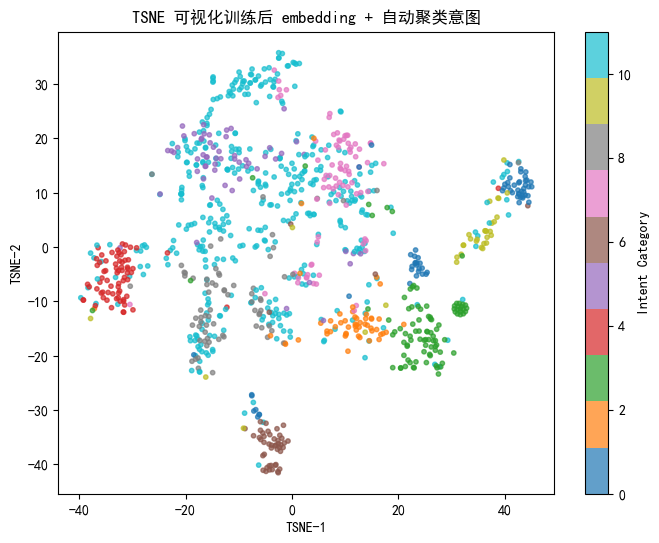

In [17]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

tsne_file = "../cache/tsne_2d.npy"
if os.path.exists(tsne_file):
    embedding_2d = np.load(tsne_file)
else:
    tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    embedding_2d = tsne.fit_transform(embeddings[:1000])
    np.save(tsne_file, embedding_2d)

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    embedding_2d[:,0], embedding_2d[:,1],
    s=10, c=df['intent_category'][:1000], cmap='tab10', alpha=0.7
)
plt.title("TSNE 可视化训练后 embedding + 自动聚类意图")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.colorbar(scatter, label="Intent Category")
plt.show()
